# Task 1: Data Preprocessing

**Student Dropout and Academic Success Dataset**

This notebook covers:
1. Loading and inspecting the dataset
2. Handling missing values
3. Encoding categorical features
4. Standardizing numerical features
5. Summary of observed patterns and insights

In [1]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing utilities
from src.preprocessing import (
    load_data,
    get_feature_types,
    handle_missing_values,
    encode_features,
    standardize_features,
)

# Import data fetcher — auto-downloads dataset if not present
from src.fetch_data import download_dataset

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Load and Inspect Data

In [2]:
# Download raw data (skipped if already present)
data_dir = os.path.join(project_root, "data")
download_dataset(data_dir=data_dir)

# Load raw data
X, y = load_data(data_dir=data_dir)

Data files already exist.
Loaded 4424 samples, 36 features
Target classes: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794


In [3]:
print("Feature Data Types:")
print(X.dtypes.value_counts())
print(f"\nTotal features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

Feature Data Types:
int64      29
float64     7
Name: count, dtype: int64

Total features: 36
Total samples: 4424


In [4]:
print("Basic Statistics (first 10 features):")
X.iloc[:, :10].describe().T

Basic Statistics (first 10 features):


,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance,4424.0,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


## 2. Feature Type Classification

Features are classified into four groups based on their semantics:

- **Nominal**: Unordered categories (e.g., marital status, course)
- **Binary**: 0/1 indicator variables (e.g., gender, scholarship)
- **Count**: Integer counts (e.g., enrolled credits, approved credits)
- **Continuous**: Floating-point values (e.g., admission grade, GDP)

In [5]:
# Get feature type classification
feature_types = get_feature_types(X)

print(f"Nominal features ({len(feature_types['nominal'])}):")
for f in feature_types["nominal"]:
    print(f"  - {f} (unique: {X[f].nunique()})")

print(f"\nBinary features ({len(feature_types['binary'])}):")
for f in feature_types["binary"]:
    print(f"  - {f}")

print(f"\nCount features ({len(feature_types['count'])}):")
for f in feature_types["count"]:
    print(f"  - {f}")

print(f"\nContinuous features ({len(feature_types['continuous'])}):")
for f in feature_types["continuous"]:
    print(f"  - {f}")

Nominal features (8):
  - Marital Status (unique: 6)
  - Application mode (unique: 18)
  - Course (unique: 17)
  - Nacionality (unique: 21)
  - Mother's qualification (unique: 29)
  - Father's qualification (unique: 34)
  - Mother's occupation (unique: 32)
  - Father's occupation (unique: 46)

Binary features (8):
  - Daytime/evening attendance
  - Displaced
  - Educational special needs
  - Debtor
  - Tuition fees up to date
  - Gender
  - Scholarship holder
  - International

Count features (13):
  - Age at enrollment
  - Application order
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (without evaluations)
  - Previous qualificati

## 3. Target Distribution

The dataset contains three classes: **Graduate** (majority class), **Dropout**, and **Enrolled**.

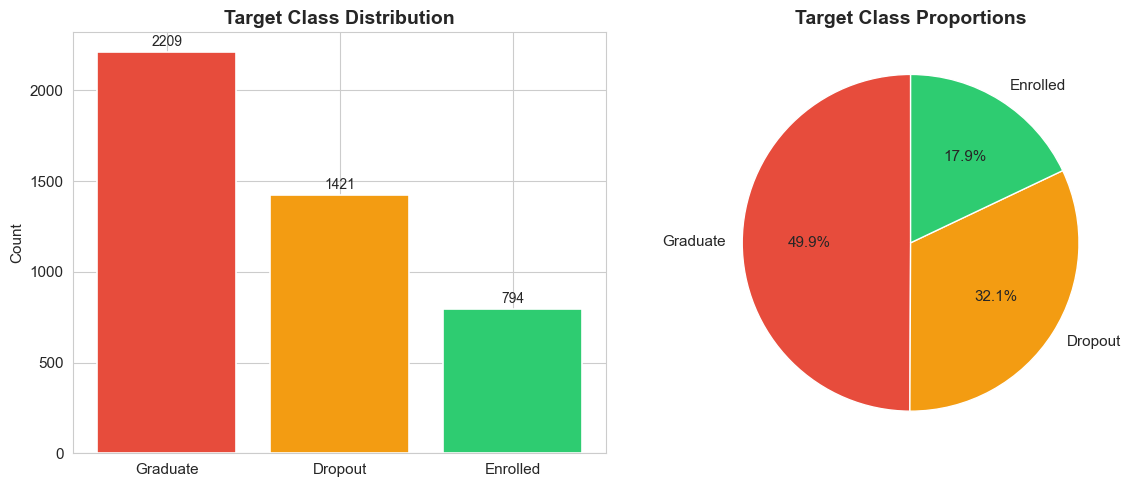

In [6]:
# Map numeric labels to class names
target_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
y_named = y.map(target_names)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = y_named.value_counts()
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Target Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
# Annotate count and percentage on top of bars
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, f"{val}", ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Target Class Proportions", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**Observation**: The dataset exhibits **class imbalance** — Graduate (49.9%) dominates, Enrolled (17.9%) is the smallest. This may affect model training and evaluation.

## 探索性数据分析 (EDA) / Exploratory Data Analysis

在进入特征工程之前，先通过可视化手段探索数据的分布特征和类别差异。
Before feature engineering, we explore data distributions and class-level differences visually.

/tmp/ipykernel_1146576/1748398048.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Target", y="value", ax=ax,
/tmp/ipykernel_1146576/1748398048.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Target", y="value", ax=ax,
/tmp/ipykernel_1146576/1748398048.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Target", y="value", ax=ax,
/tmp/ipykernel_1146576/1748398048.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

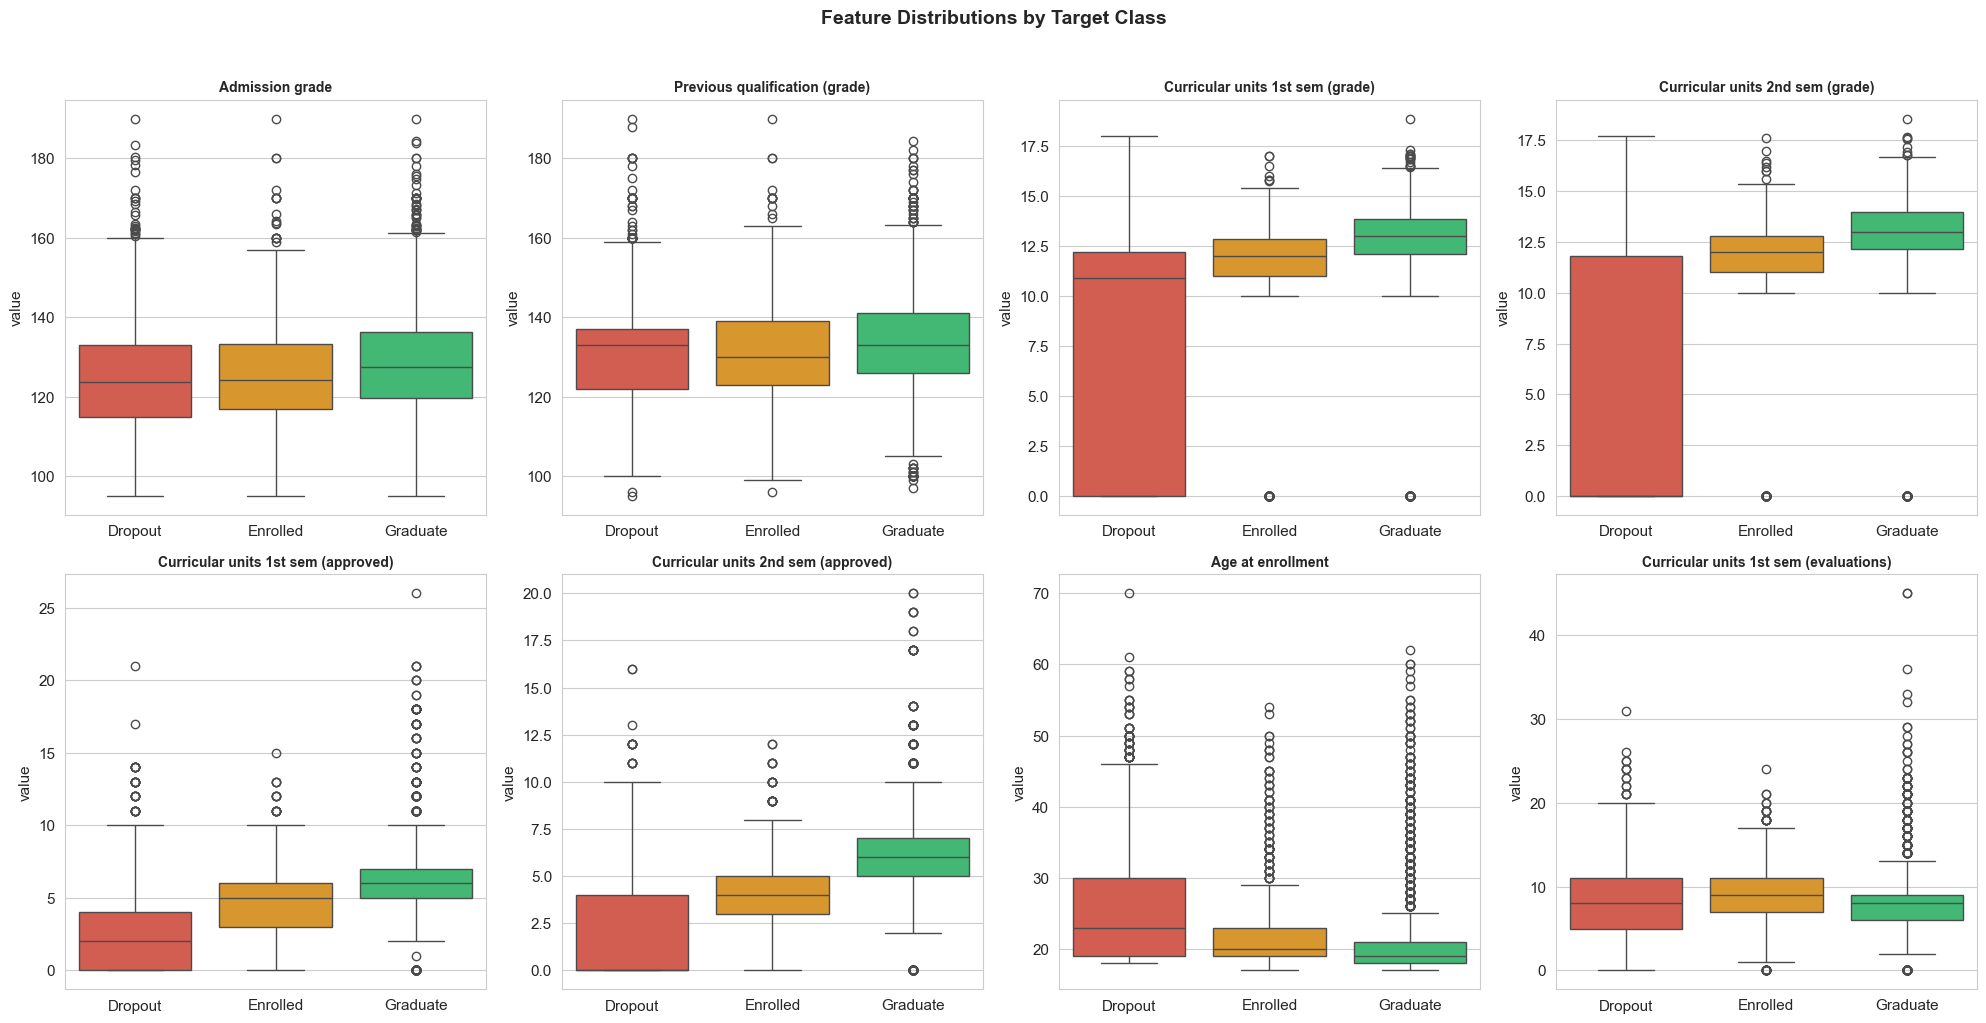

In [7]:
# 按 Target 分组的关键特征箱线图 / Boxplots of key features grouped by Target
import seaborn as sns

key_features = [
    "Admission grade", "Previous qualification (grade)",
    "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)",
    "Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)",
    "Age at enrollment", "Curricular units 1st sem (evaluations)",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
target_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}

for ax, feat in zip(axes.flat, key_features):
    plot_df = pd.DataFrame({"value": X[feat], "Target": y.map(target_names)})
    sns.boxplot(data=plot_df, x="Target", y="value", ax=ax,
                palette={"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#2ecc71"},
                order=["Dropout", "Enrolled", "Graduate"])
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Feature Distributions by Target Class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
os.makedirs(os.path.join(project_root, "data", "plots"), exist_ok=True)
plt.savefig(os.path.join(project_root, "data", "plots", "01_eda_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

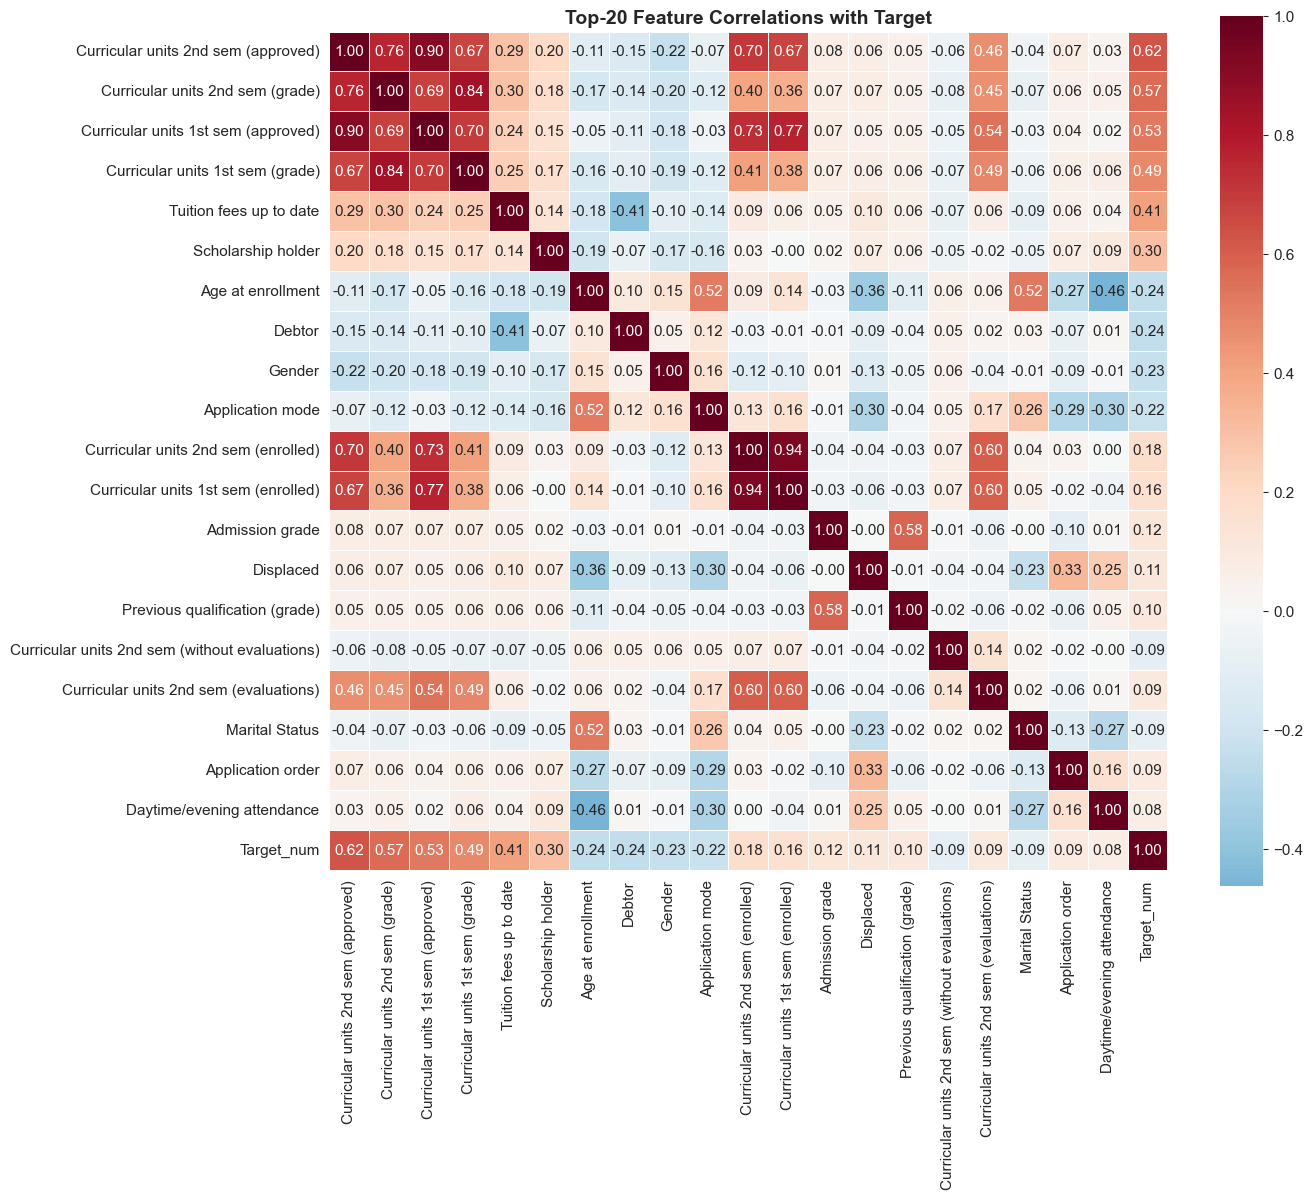

In [8]:
# 特征与 Target 的相关性热力图 / Correlation heatmap (top-20 features vs target)
combined = X.copy()
combined["Target_num"] = y.values

# 只选数值列进行相关性分析 / Only use numeric columns
numeric_cols = combined.select_dtypes(include=[np.number]).columns
corr_with_target = combined[numeric_cols].corr()["Target_num"].drop("Target_num").abs().sort_values(ascending=False)
top20 = corr_with_target.head(20).index.tolist()

corr_matrix = combined[top20 + ["Target_num"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title("Top-20 Feature Correlations with Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(project_root, "data", "plots", "01_eda_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

3.0.2


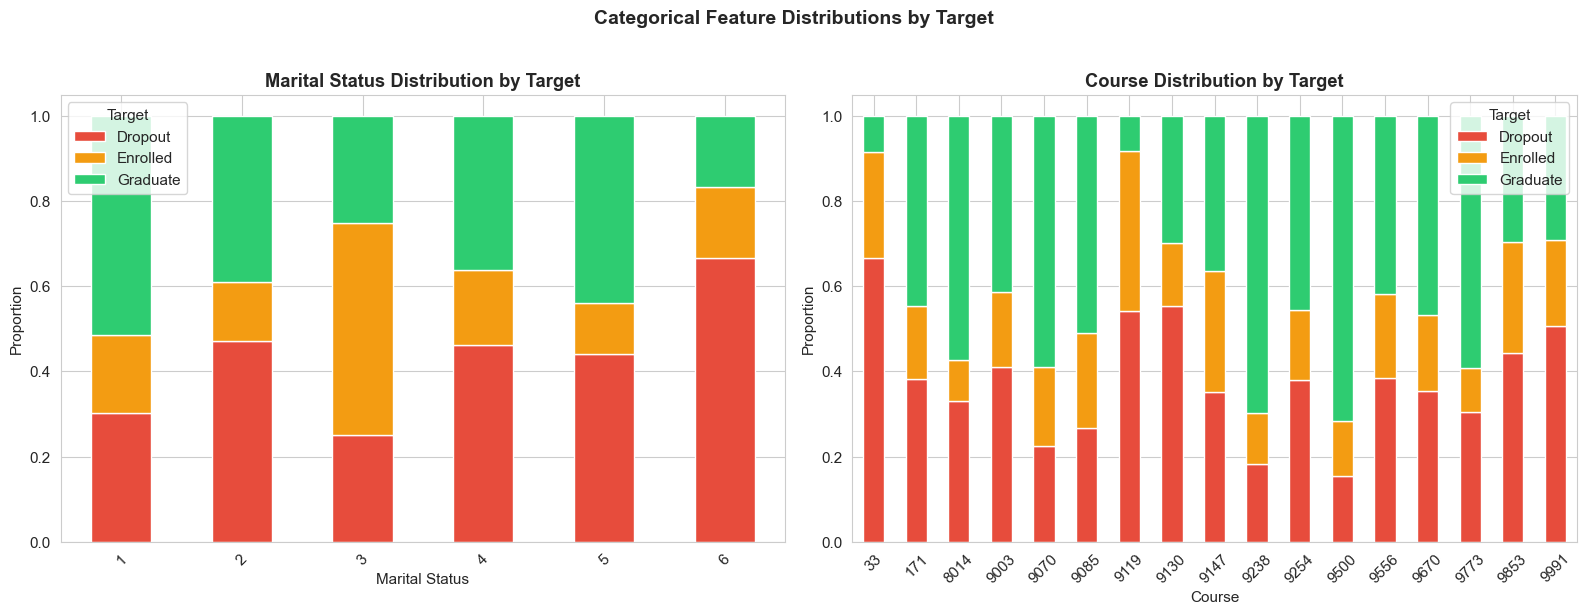

In [9]:
print(pd.__version__)

# 关键类别特征按 Target 的堆叠分布 / Categorical feature distributions by Target
cat_features = ["Marital Status", "Course"]
target_names_map = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}

fig, axes = plt.subplots(1, len(cat_features), figsize=(8 * len(cat_features), 6))
if len(cat_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, cat_features):
    ct = pd.crosstab(X[feat], y.map(target_names_map), normalize="index")
    ct[["Dropout", "Enrolled", "Graduate"]].plot(
        kind="bar", stacked=True, ax=ax,
        color=["#e74c3c", "#f39c12", "#2ecc71"],
    )
    ax.set_title(f"{feat} Distribution by Target", fontweight="bold")
    ax.set_ylabel("Proportion")
    ax.set_xlabel(feat)
    ax.legend(title="Target")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Categorical Feature Distributions by Target", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "data", "plots", "01_eda_categorical_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

### EDA 关键发现 / Key EDA Findings

1. **成绩分布差异显著**: Graduate 学生的 1st/2nd semester grades 明显高于 Dropout，Enrolled 介于二者之间。Admission grade 三类差异较小。
2. **年龄特征**: Dropout 学生的年龄分布偏大（中位数更高），表明成熟学生更容易辍学。
3. **课程影响**: 不同 Course 的辍学比例差异很大，某些课程的辍学率明显高于平均水平。
4. **相关性**: Curricular units 的 approved/grade 指标与 Target 相关性最强（|r| > 0.3），是后续模型最重要的预测因子。

## 4. Missing Value Analysis

In [10]:
X_clean, missing_info = handle_missing_values(X, strategy="median")
print(f"\nMissing info: {missing_info}")

No missing values found.

Missing info: {'total_missing': 0, 'missing_per_column': {}, 'strategy': 'median'}


**Result**: No missing values were detected in the dataset. This is a complete dataset.

## 5. Feature Encoding & Domain Features

Nominal categorical features are one-hot encoded to avoid introducing ordinal relationships.
Domain features (academic ratios, financial risk, etc.) are added to the full dataset before encoding.

In [11]:
# Add domain features first, then one-hot encode
from src.feature_engineering import add_all_engineered_features

X_full_eng = add_all_engineered_features(X_clean)
print(f'After domain features: {X_full_eng.shape[1]} features (+ {X_full_eng.shape[1] - X_clean.shape[1]} new)')

# Get feature types for the augmented dataset
feature_types_eng = get_feature_types(X_full_eng)

# One-hot encode nominal features
X_encoded = encode_features(X_full_eng, feature_types_eng, method="onehot")
print(f"After one-hot encoding: {X_encoded.shape[1]} features")

After domain features: 61 features (+ 25 new)
One-hot encoded 8 nominal features. New shape: (4424, 256)
After one-hot encoding: 256 features


## 6. Feature Standardization

Continuous and count features are standardized to zero mean and unit variance. 

In [12]:
X_scaled, scaler = standardize_features(X_encoded, feature_types_eng, fit=True)
print(f"Final shape: {X_scaled.shape}")

Standardized 45 numerical features (fit).
Final shape: (4424, 256)


In [13]:
print("Standardized Features (sample):")
scale_cols = feature_types_eng["continuous"] + feature_types_eng["count"]
scale_cols = [c for c in scale_cols if c in X_scaled.columns]
X_scaled[scale_cols].describe().T

Standardized Features (sample):


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,-3.589654e-16,1.000113,-2.852337,-0.577342,0.036907,0.560156,4.351815
Admission grade,4424.0,-9.708930e-16,1.000113,-2.208378,-0.626926,-0.060642,0.540172,4.352230
Curricular units 1st sem (grade),4424.0,-1.702476e-16,1.000113,-2.197102,0.074163,0.339635,0.569711,1.700182
Curricular units 2nd sem (grade),4424.0,3.212219e-17,1.000113,-1.963489,0.099764,0.378064,0.595585,1.600935
Unemployment rate,4424.0,-5.460771e-17,1.000113,-1.489043,-0.813253,-0.175007,0.876222,1.739731
Inflation rate,4424.0,1.445498e-16,1.000113,-1.466871,-0.671242,0.124386,0.992345,1.787974
GDP,4424.0,2.569775e-17,1.000113,-1.789667,-0.749872,0.140122,0.787790,1.545607
Age at enrollment,4424.0,-1.027910e-16,1.000113,-0.825778,-0.562168,-0.430363,0.228663,6.159894
Application order,4424.0,-1.043971e-16,1.000113,-1.315309,-0.554068,-0.554068,0.207173,5.535860
Curricular units 1st sem (approved),4424.0,3.051608e-17,1.000113,-1.521257,-0.551604,0.094832,0.418050,6.882407


## 7. Feature Correlation with Target

In [14]:
# Feature correlation analysis is included in the EDA section above.

## 8. Advanced Encoding (Target Encoding + Train/Val/Test Split)

We split the data first, then apply OOF target encoding and standardization only within the training set.
This produces train/val/test sets for use in notebooks 04 and 05.

Domain features were added in Section 5 (X_full_eng is already available).

### Train / Val / Test Split + OOF Target Encoding + Standardization

In [15]:
# Columns to target-encode (high cardinality nominals)
high_card_cols = [
    'Course',
    "Mother's occupation",
    "Father's occupation",
    "Mother's qualification",
    "Father's qualification",
    'Nacionality',
    'Application mode',
]

from sklearn.model_selection import train_test_split
from src.feature_engineering import apply_target_encoding_oof, target_encode_column

# Step 1: split into 80% temp + 20% test first (for stratification)
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X_full_eng, y, test_size=0.2, random_state=42, stratify=y
)
# Step 2: split temp into 70% train + 15% val
val_ratio = 0.15 / 0.8
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw, y_train_val, test_size=val_ratio, random_state=42, stratify=y_train_val
)
print(f'Split: train={X_train_raw.shape[0]}, val={X_val_raw.shape[0]}, test={X_test_raw.shape[0]}')

# Step 2: OOF target encoding for train (avoids leakage), full mean on val and test
X_train_te, X_test_te = apply_target_encoding_oof(
    X_train_raw, X_test_raw, y_train,
    columns=high_card_cols, n_folds=5, smoothing=10.0
)
# Encode val using full training mean
X_val_te = X_val_raw.copy()
for col in high_card_cols:
    if col not in X_val_te.columns:
        continue
    _, val_enc = target_encode_column(X_train_raw[col], X_val_raw[col], y_train, smoothing=10.0)
    X_val_te[col] = val_enc.values
print(f'After target encoding: {X_train_te.shape[1]} features')

Split: train=2875, val=664, test=885
After target encoding: 61 features


### Feature Selection by Importance (Top-50)

In [16]:
# 使用 RandomForestClassifier 进行特征重要性排序（不依赖 prediction 模块）
# Use RandomForestClassifier for feature importance ranking (no prediction module dependency)
from sklearn.ensemble import RandomForestClassifier
from src.feature_engineering import select_features_by_importance

rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X_train_te, y_train)

# 选择前50个最重要的特征 / Select top-50 features by importance
X_train_top, top_features = select_features_by_importance(X_train_te, model=rf_sel, top_k=50)
X_val_top = X_val_te[top_features]
X_test_top = X_test_te[top_features]

print(f'\nTop features:')
top_imp = pd.Series(rf_sel.feature_importances_, index=X_train_te.columns).nlargest(15)
print(top_imp.round(4).to_string())

Selected top 50 features out of 61

Top features:
overall_approval_rate                  0.1087
approval_rate_2nd                      0.0693
Curricular units 2nd sem (approved)    0.0595
approval_rate_1st                      0.0479
total_approved                         0.0450
grade_per_evaluation_2nd               0.0382
Curricular units 2nd sem (grade)       0.0368
grade_per_evaluation_1st               0.0328
Curricular units 1st sem (grade)       0.0286
Course                                 0.0280
Admission grade                        0.0245
Tuition fees up to date                0.0244
Curricular units 1st sem (approved)    0.0224
Mother's occupation                    0.0203
Previous qualification (grade)         0.0200


## 9. Summary & Insights

### Baseline Pipeline (Section 1-7)
- **Domain features**: 20 new features added to full dataset (no target leakage)
- **One-hot encoding**: 8 nominal features encoded
- **Standardization**: Fit on full data
- Output: `features_processed.csv` (4424 samples)

### Engineered Pipeline (Section 8)
1. **Train/Val/Test split first**: 70/15/15 stratified split (before any target-based operations)
2. **OOF target encoding**: Train encoded via 5-fold CV; val/test encoded using full training mean
3. **Standardization**: Fit on train only, transform val and test
4. **Feature selection**: Top-50 by Random Forest importance (fit on train only)
- Output: `features_engineered_train/val/test.csv`

### Key Observations
- Domain features (approval rates, financial risk) are strong predictors
- OOF target encoding avoids target leakage within the training set
- Split-then-encode ensures val and test sets remain truly unseen

In [17]:
# Save baseline (one-hot + domain features + standardization, full data)
X_scaled.to_csv(os.path.join(project_root, 'data', 'features_processed.csv'), index=False)
y.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_processed.csv'), index=False)
print(f'Baseline saved: features_processed.csv ({X_scaled.shape[0]} samples, {X_scaled.shape[1]} features)')

# Save engineered train/val/test sets (target encoding + top-50 selection)
X_train_top.to_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'), index=False)
y_train.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv'), index=False)
print(f'Train saved: features_engineered_train.csv ({X_train_top.shape[0]} samples)')

X_val_top.to_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'), index=False)
y_val.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv'), index=False)
print(f'Val saved: features_engineered_val.csv ({X_val_top.shape[0]} samples)')

X_test_top.to_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'), index=False)
y_test.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv'), index=False)
print(f'Test saved: features_engineered_test.csv ({X_test_top.shape[0]} samples)')

Baseline saved: features_processed.csv (4424 samples, 256 features)
Train saved: features_engineered_train.csv (2875 samples)
Val saved: features_engineered_val.csv (664 samples)
Test saved: features_engineered_test.csv (885 samples)
